# Chapter 1: Exploratory Data Analysis
> (c) 2019-2026 Peter C. Bruce, Andrew Bruce, Peter Gedeck

In [1]:
library(corrplot)
library(ellmer)
library(gmodels)
library(matrixStats)
library(tidyverse)

set.seed(123)

# Location of the data files. Adjust this path if you keep the data
# files in a different directory.
DATA_DIR <- '../../data'


corrplot 0.95 loaded



── Attaching core tidyverse packages ───────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     


── Conflicts ─────────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::count()  masks matrixStats::count()
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Exploratory Data Analysis
### Data Dictionaries and Catalogs

In [1]:
system_prompt <- "
Improve the attached data dictionary and return it in YAML format. In addition to
the description of features, provide name, description, source, and
size of the dataset.

For each feature, provide the following information:
- feature name
- readable variable name (if required)
- definition of the variable
- data type
- measurement units
- allowed values (for categorical or nominal features, but only if you are sure)
"

data_dictionary <- "
name: ebay Auctions
description: >
    The dataset eBayAuctions.csv contains information on 1972 auctions that
    transacted on eBay.com during May-June 2004.
source: Copyright 2016 Galit Shmueli and Peter Bruce
size:
    observations: 1972
    features: 8
features:
    Category: Category of the auctioned item
    currency: \"US: US dollar, GBP: English pound, EUR: Euro\"
    sellerRating: >
        a rating by eBay, as a function of the number of \"good\" and  \"bad\"
        transactions the seller had on eBay
    Duration: Number of days the auction lasted (set by seller at auction start)
    endDay: Day of week that the auction closed
    ClosePrice: Price item sold at (converted into USD)
    OpenPrice: Initial price set by the seller (converted into USD)
    Competitive?: whether the auction had a single bid (0) or more (1)
"

message <- paste(c(
  "Here is the data dictionary in YAML format:",
  data_dictionary,
  "First ten lines of the dataset in CSV format:",
  read_csv(file.path(DATA_DIR, "eBayAuctions.csv.gz"), show_col_types = FALSE) %>%
    sample_n(10) %>%
    format_delim(delim = ",", na = "")
), collapse = "\n")

chat <- chat_openai(system_prompt, model = "gpt-4o-mini")
response <- chat$chat(message)

Here's an improved version of your data dictionary in YAML format, with added details for each feature:

```yaml
name: ebay Auctions
description: >
    The dataset eBayAuctions.csv contains information on 1972 auctions that
    transacted on eBay.com during May and June of 2004.
source: Copyright 2016 Galit Shmueli and Peter Bruce
size:
    observations: 1972
    features: 8
features:
    - feature_name: Category
      readable_variable_name: Auction Item Category
      definition: The category under which the auctioned item is listed.
      data_type: string
      measurement_units: None
      allowed_values: 
        - Music/Movie/Game
        - Coins/Stamps
        - Automotive
        - Health/Beauty
        - Toys/Hobbies
        - Collectibles

    - feature_name: currency
      readable_variable_name: Currency Type
      definition: The currency in which the auction was conducted.
      data_type: string
      measurement_units: None
      allowed_values:
        - US
        - 

### Estimates of Location
#### Example: Location Estimates of Population and Murder Rates

In [1]:
state <- read_csv(file.path(DATA_DIR, "state.csv"), show_col_types = FALSE)
population <- state[["Population"]]
mean(population)
mean(population, trim = 0.1)
median(population)

[1] 6162876

[1] 4783697

[1] 4436370

In [1]:
weighted.mean(state[["Murder.Rate"]], w = state[["Population"]])
weightedMedian(state[["Murder.Rate"]], w = state[["Population"]])

[1] 4.445834

[1] 4.4

### Estimates of Variability
#### Example: Variability Estimates of State Population

In [1]:
sd(state[["Population"]])
IQR(state[["Population"]])
mad(state[["Population"]])

[1] 6848235

[1] 4847308

[1] 3849870

### Exploring the Data Distribution
#### Percentiles and Boxplots

In [1]:
quantile(state[["Murder.Rate"]], p = c(0.05, 0.25, 0.5, 0.75, 0.95))

5%   25%   50%   75%   95% 
1.600 2.425 4.000 5.550 6.510

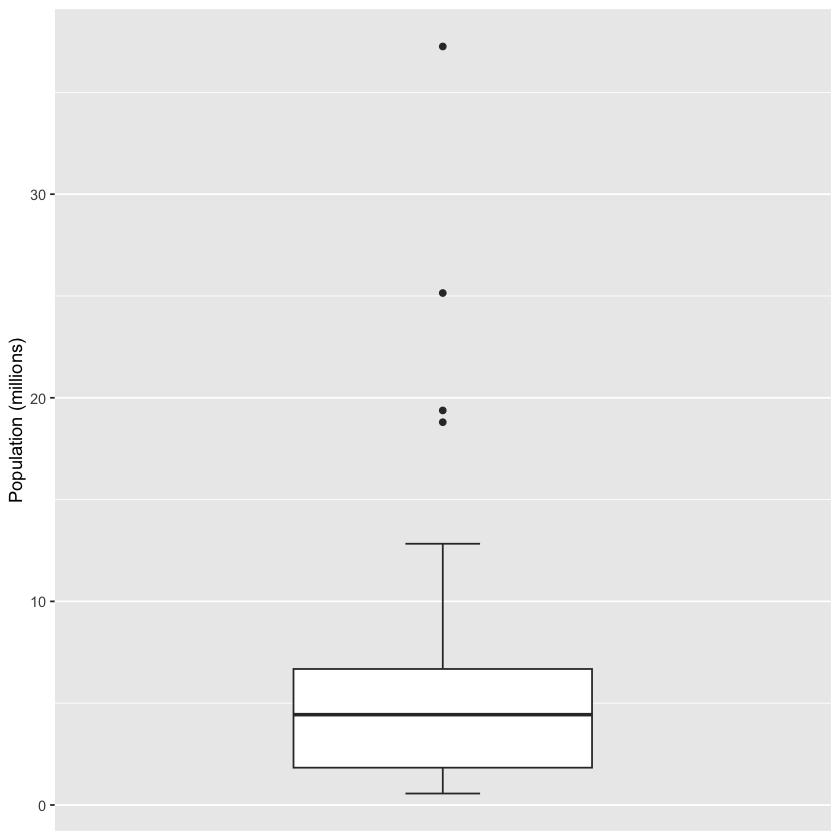

In [1]:
ggplot(state, aes(y = Population / 1000000)) +
  geom_boxplot(staplewidth = 0.25) +
  labs(y = "Population (millions)") +
  scale_x_discrete(labels = NULL, breaks = NULL)

#### Frequency Tables and Histograms

In [1]:
breaks <- seq(
  from = min(state[["Population"]]),
  to = max(state[["Population"]]), length = 11)
state %>%
  mutate(BinRange = cut(Population, breaks = breaks,
      right = TRUE, include.lowest = TRUE)) %>%
  count(BinRange, .drop = FALSE)

BinRange,n
<fct>,<int>
"[5.64e+05,4.23e+06]",24
"(4.23e+06,7.9e+06]",14
"(7.9e+06,1.16e+07]",6
"(1.16e+07,1.52e+07]",2
"(1.52e+07,1.89e+07]",1
"(1.89e+07,2.26e+07]",1
"(2.26e+07,2.62e+07]",1
"(2.62e+07,2.99e+07]",0
"(2.99e+07,3.36e+07]",0


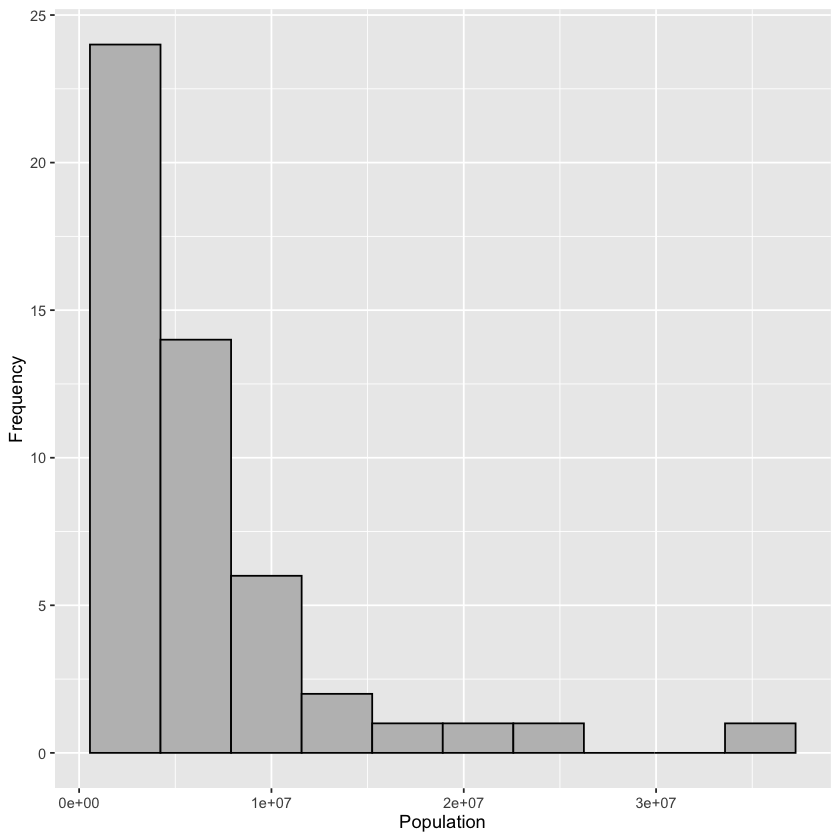

In [1]:
ggplot(state, aes(x = Population)) +
  geom_histogram(breaks = breaks, fill = "grey", color = "black") +
  labs(y = "Frequency")

#### Density Plots and Estimates

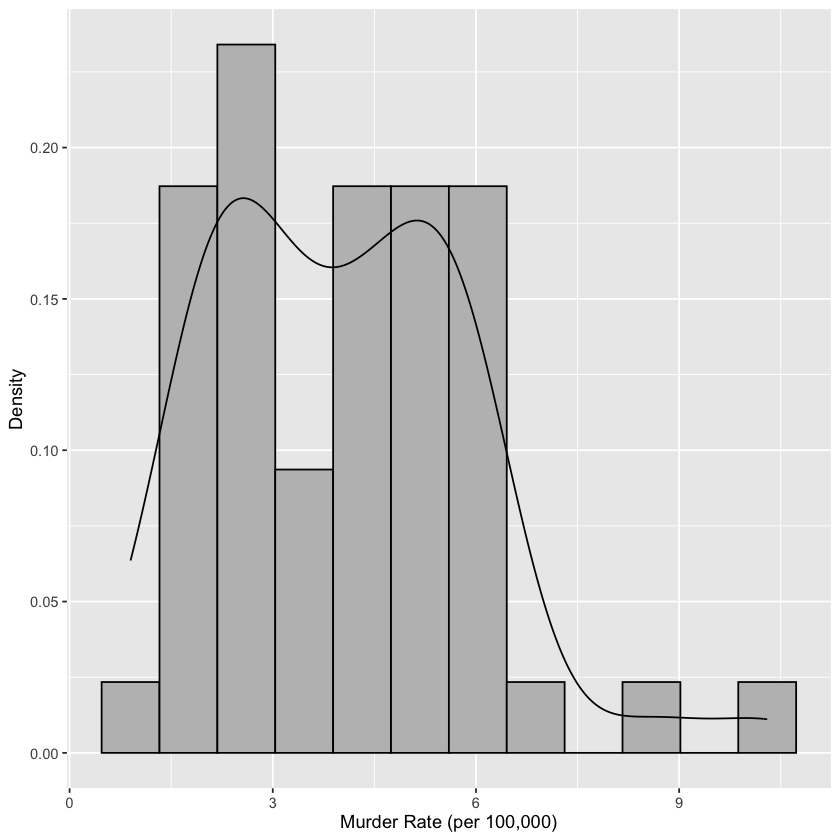

In [1]:
ggplot(state, aes(x = Murder.Rate)) +
  geom_histogram(aes(y = after_stat(density)), bins = 12, fill = "grey",
    color = "black") +
  geom_density() +
  labs(x = "Murder Rate (per 100,000)", y = "Density")

### Exploring Binary and Categorical Data

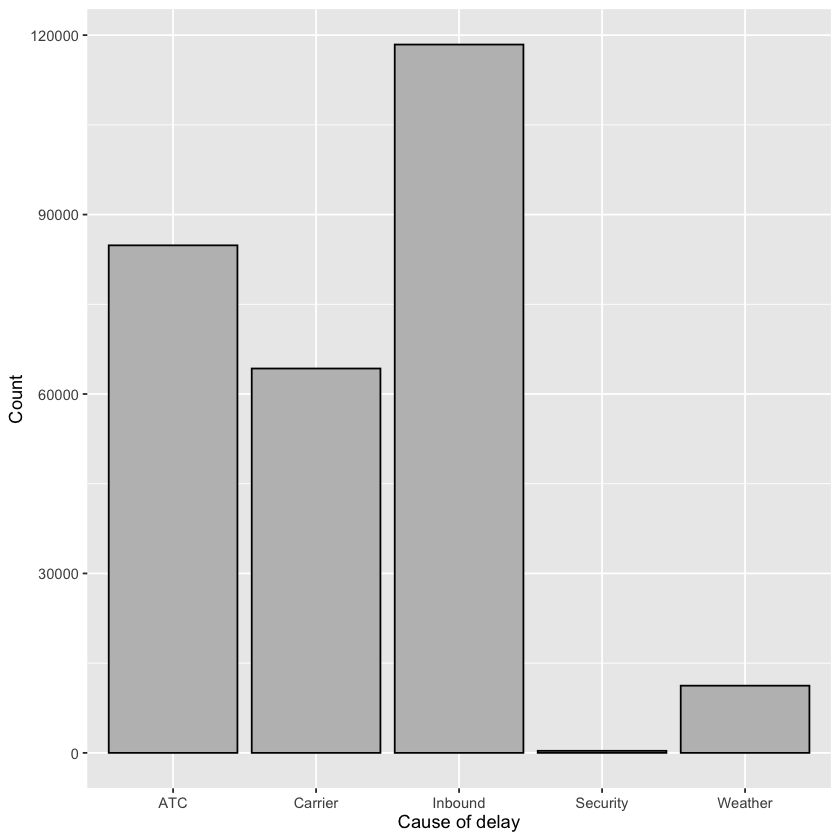

In [1]:
dfw <- read_csv(file.path(DATA_DIR, "dfw_airline.csv"), show_col_types = FALSE) %>%
  pivot_longer(everything())
ggplot(dfw, aes(x = name, y = value)) +
  geom_col(color = "black", fill = "grey") +
  labs(x = "Cause of delay", y = "Count")

### Correlation

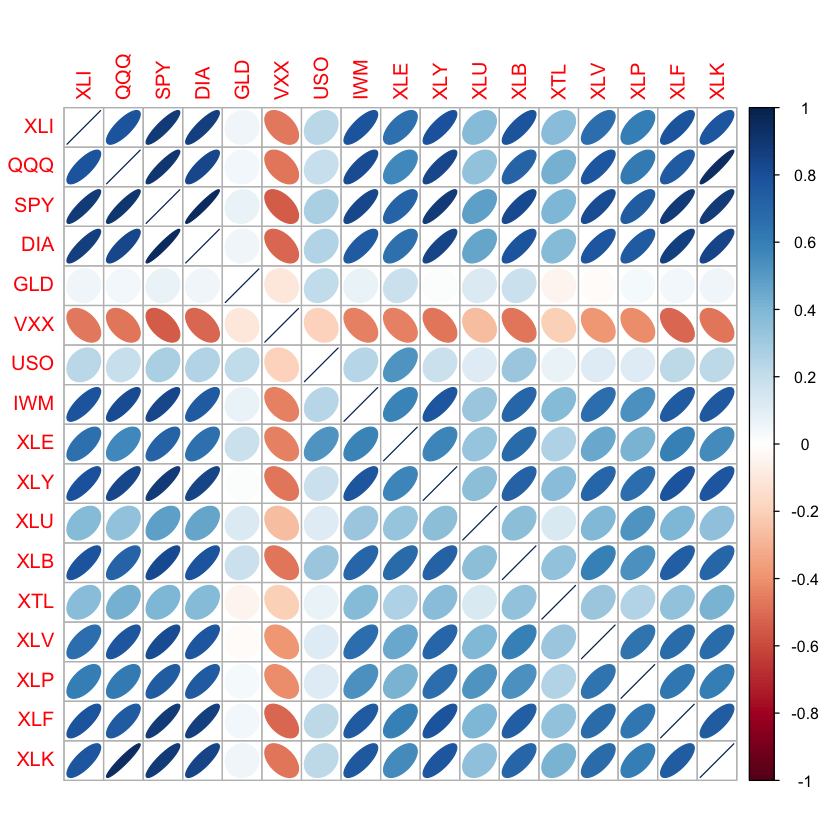

In [1]:
sp500_px <- read_csv(file.path(DATA_DIR, "sp500_data.csv.gz"), show_col_types = FALSE)
sp500_sym <- read_csv(file.path(DATA_DIR, "sp500_sectors.csv"), show_col_types = FALSE)
etf_symbols <- sp500_sym %>%
  filter(sector == "etf") %>%
  pull(symbol)
etfs <- sp500_px %>%
  filter(Date > "2012-07-01") %>%
  select(all_of(etf_symbols))
corrplot(cor(etfs), method = "ellipse")

In [1]:
corrplot(cor(etfs), method = "ellipse")

agg_record_c4cf7aff1bcb 
                      2

#### Scatterplots

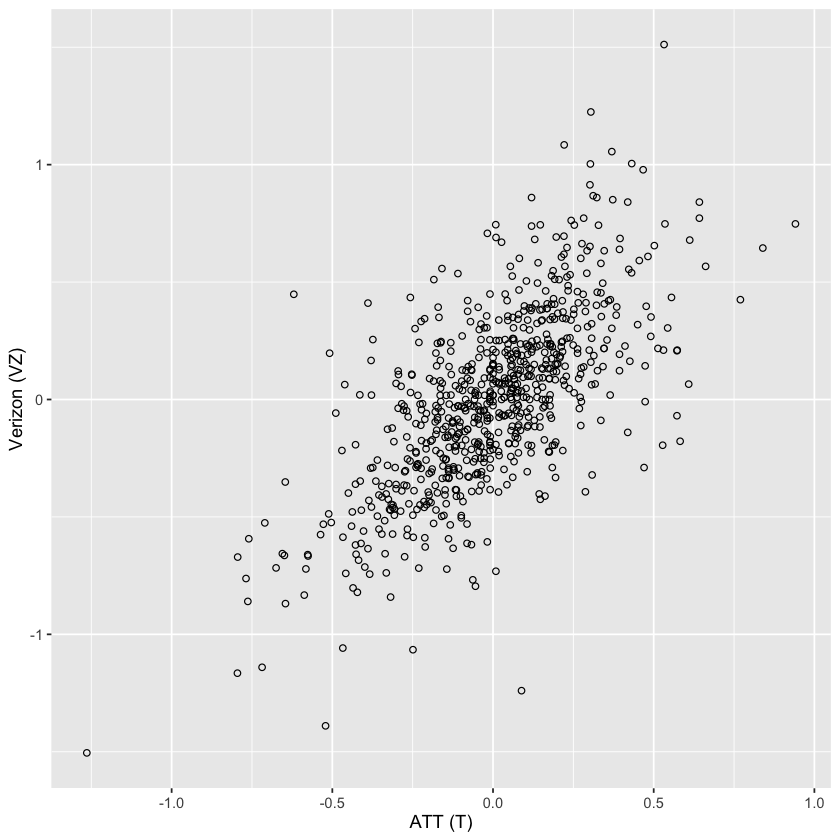

In [1]:
ggplot(sp500_px %>% filter(Date > "2012-07-01"), aes(x = T, y = VZ)) +
  geom_point(shape = 1) +
  labs(x = "ATT (T)", y = "Verizon (VZ)")

### Exploring Two or More Variables
#### Hexagonal Binning and Contours pass:[<span class#"keep-together">(Plotting Numeric-Versus-Numeric Data)</span>]

In [1]:
kc_tax <- read_csv(file.path(DATA_DIR, "kc_tax.csv.gz"), show_col_types = FALSE)
kc_tax0 <- kc_tax %>%
  filter(TaxAssessedValue < 750000,
    SqFtTotLiving > 100,
    SqFtTotLiving < 3500)
nrow(kc_tax0)

[1] 432693

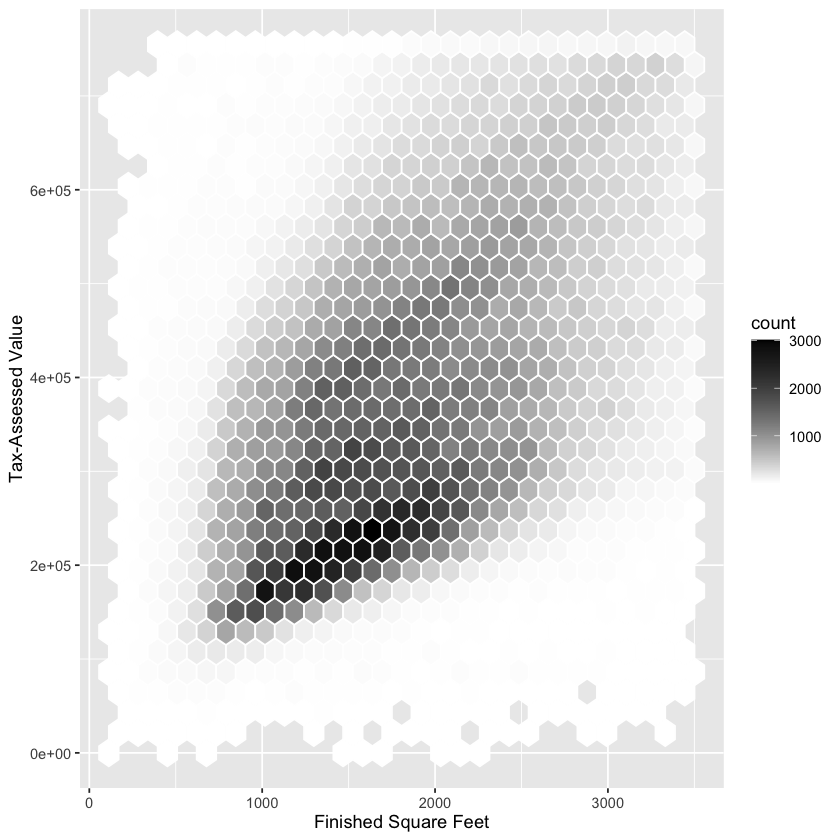

In [1]:
ggplot(kc_tax0, (aes(x = SqFtTotLiving, y = TaxAssessedValue))) +
  geom_hex(color = "white") +
  scale_fill_gradient(low = "white", high = "black") +
  labs(x = "Finished Square Feet", y = "Tax-Assessed Value")

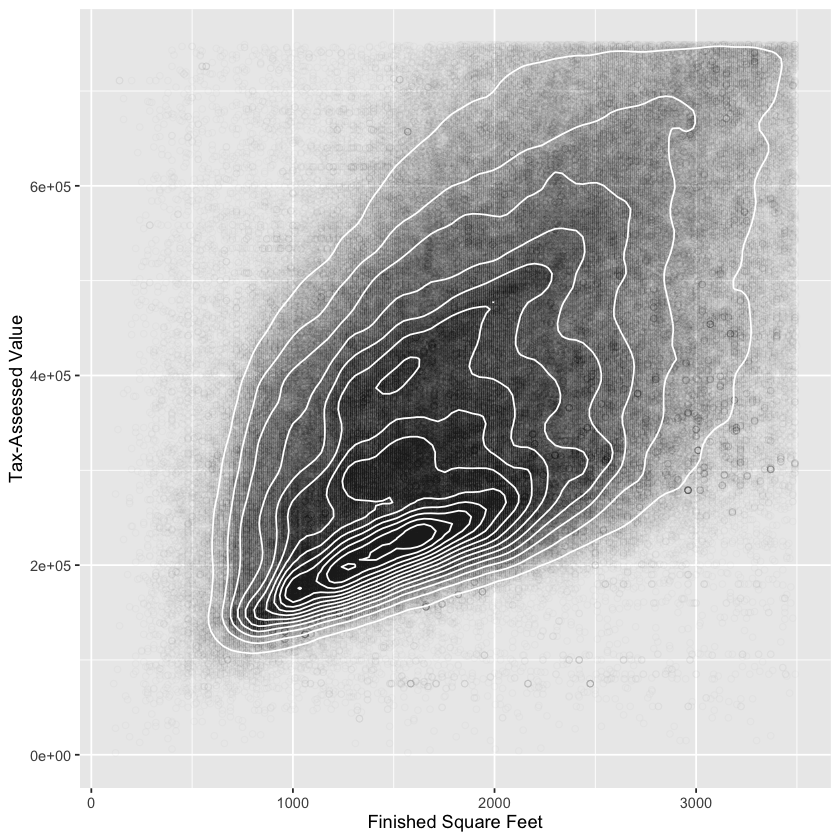

In [1]:
ggplot(kc_tax0, aes(SqFtTotLiving, TaxAssessedValue)) +
  geom_point(shape = 1, alpha = 0.02) +
  geom_density2d(color = "white") +
  labs(x = "Finished Square Feet", y = "Tax-Assessed Value")

#### Two Categorical Variables

In [1]:
lc_loans <- read_csv(file.path(DATA_DIR, "lc_loans.csv"), show_col_types = FALSE)
x_tab <- CrossTable(lc_loans$grade, lc_loans$status,
  prop.c = FALSE, prop.chisq = FALSE, prop.t = FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|-------------------------|

 
Total Observations in Table:  450961 

 
               | lc_loans$status 
lc_loans$grade | Charged Off |     Current |  Fully Paid |        Late |   Row Total | 
---------------|-------------|-------------|-------------|-------------|-------------|
             A |        1562 |       50051 |       20408 |         469 |       72490 | 
               |       0.022 |       0.690 |       0.282 |       0.006 |       0.161 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             B |        5302 |       93852 |       31160 |        2056 |      132370 | 
               |       0.040 |       0.709 |       0.235 |       0.016 |       0.294 | 
---------------|-------------|-------------|-------------|-------------|-------------|
             C |        6023 |       88928 |       23147 |        2777 |      120875 | 
 

In [1]:
# Alternative to create crosstable using tidyverse
crosstab <- lc_loans  %>%
  group_by(status, grade) %>%
  count() %>%  # adds column n with the size of each group
  pivot_wider(id_cols = grade, names_from = status, values_from = n)
crosstab

grade,Charged Off,Current,Fully Paid,Late
<chr>,<int>,<int>,<int>,<int>
A,1562,50051,20408,469
B,5302,93852,31160,2056
C,6023,88928,23147,2777
D,5007,53281,13681,2308
E,2842,24639,5949,1374
F,1526,8444,2328,606
G,409,1990,643,199


#### Categorical and Numeric Data

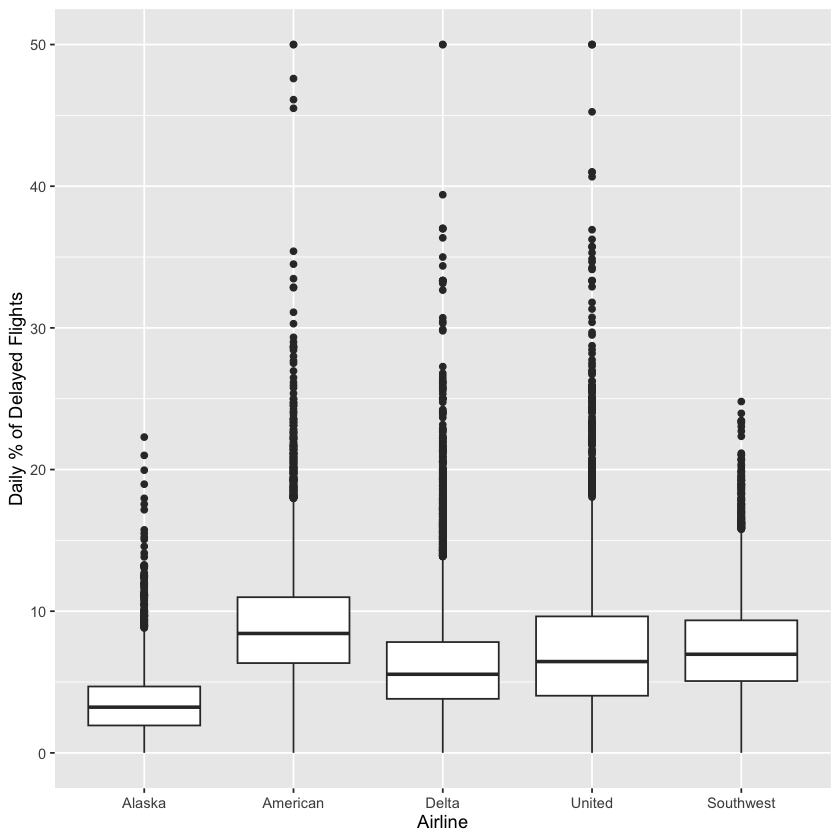

In [1]:
airline_stats <- read_csv(file.path(DATA_DIR, "airline_stats.csv"), show_col_types = FALSE) %>%
  mutate(
    airline = factor(airline,
      levels = c("Alaska", "American", "JetBlue", "Delta", "United",
        "Southwest"))
  ) %>%
  drop_na()

ggplot(airline_stats, aes(x = airline, y = pct_carrier_delay)) +
  geom_boxplot() +
  coord_cartesian(ylim = c(0, 50)) +
  labs(x = "Airline", y = "Daily % of Delayed Flights")

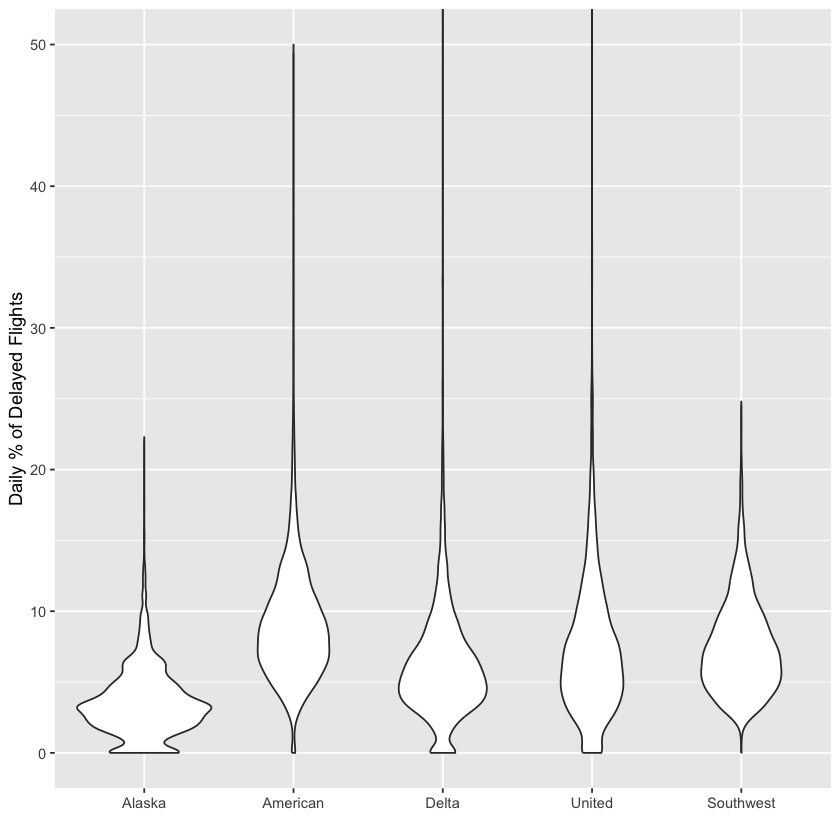

In [1]:
ggplot(data = airline_stats, aes(airline, pct_carrier_delay)) +
  geom_violin() +
  coord_cartesian(ylim = c(0, 50)) +
  labs(x = "", y = "Daily % of Delayed Flights")

#### Visualizing Multiple Variables

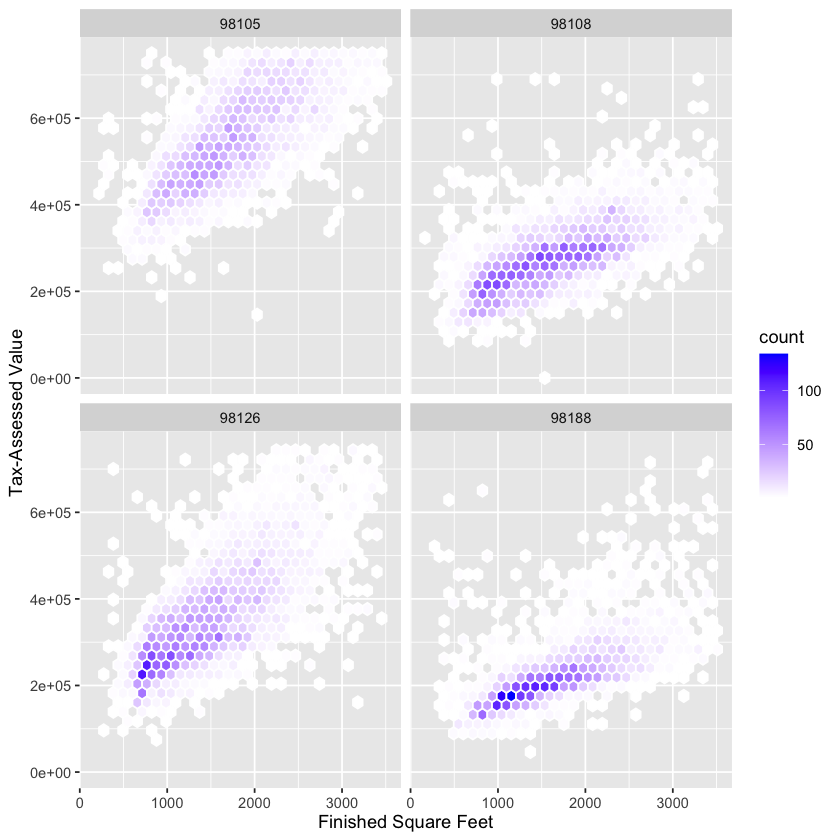

In [1]:
kc_subset <- kc_tax0 %>%
  filter(ZipCode %in% c(98188, 98105, 98108, 98126))
ggplot(kc_subset, aes(x = SqFtTotLiving, y = TaxAssessedValue)) +
  geom_hex(color = "white") +
  scale_fill_gradient(low = "white", high = "blue") +
  labs(x = "Finished Square Feet", y = "Tax-Assessed Value") +
  facet_wrap("ZipCode")

# Supplementary Material
## Table 1-2. A few rows of the data.frame state of population and murder rate by state

In [1]:
state %>%
  mutate(
    Population = formatC(Population, format = "d", digits = 0, big.mark = ","),
  ) %>%
  head(8)

State,Population,Murder.Rate,Abbreviation
<chr>,<chr>,<dbl>,<chr>
Alabama,"4,779,736",5.7,AL
Alaska,"710,231",5.6,AK
Arizona,"6,392,017",4.7,AZ
Arkansas,"2,915,918",5.6,AR
California,"37,253,956",4.4,CA
Colorado,"5,029,196",2.8,CO
Connecticut,"3,574,097",2.4,CT
Delaware,"897,934",5.8,DE


## Table 1-4. Percentiles of murder rate by state

## Table 1-5. A frequency table of population by state

## Table 1-6. Percentage of delays by cause at Dallas/Fort Worth Airport

## Table 1-7. Correlation between telecommunication stock returns

## Figure 1-6. Correlation between ETF returns (Python version)

## Figure 1-6. Correlation between ETF returns using a heat map (R version)

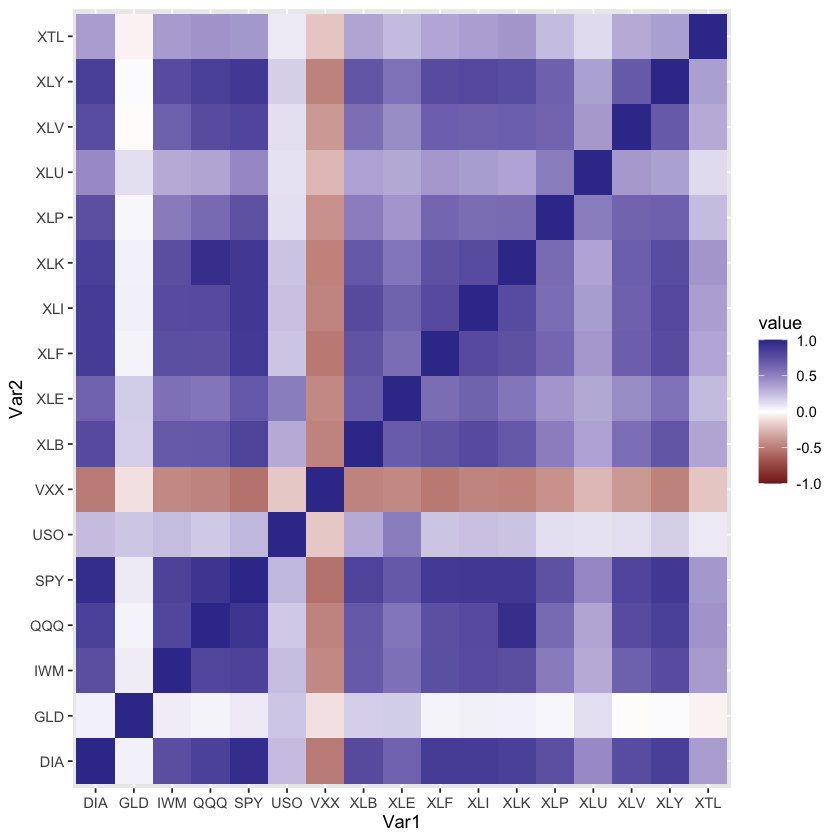

In [1]:
sp500_px <- read_csv(file.path(DATA_DIR, "sp500_data.csv.gz"), show_col_types = FALSE)
sp500_sym <- read_csv(file.path(DATA_DIR, "sp500_sectors.csv"), show_col_types = FALSE)
etf_symbols <- sp500_sym %>%
  filter(sector == "etf") %>%
  pull(symbol)
etfs <- sp500_px %>%
  filter(Date > "2012-07-01") %>%
  select(all_of(etf_symbols))
correlation_matrix <- cor(etfs) %>%
  as_tibble() %>%
  mutate(Var1 = colnames(.)) %>%
  pivot_longer(-Var1, names_to = "Var2", values_to = "value")

ggplot(correlation_matrix, aes(x = Var1, y = Var2)) +
  geom_tile(aes(fill = value)) +
  scale_fill_gradient2(limits = c(-1, 1))